<a href="https://colab.research.google.com/github/Giraffe-Shin/trading/blob/main/model/german_elec_predic_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
from google.colab import userdata

# --- 필수 설정 ---
try:
    github_token = userdata.get('GITHUB_TOKEN')
except Exception:
    github_token = 'YOUR_TOKEN_HERE'

username = 'Giraffe-Shin'
repo = 'trading'
branch = 'main'
directory_path = 'data'

# GitHub API Contents URL
url = f'https://api.github.com/repos/{username}/{repo}/contents/{directory_path}?ref={branch}'
headers = {'Authorization': f'token {github_token}'}

try:
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        items = response.json()
        # 파일 타입이 'file'이고 .csv로 끝나는 파일만 필터링
        csv_files = [item['name'] for item in items if item['type'] == 'file' and item['name'].endswith('.csv')]

        if csv_files:
            print(f"'/{directory_path}' 경로에서 발견된 CSV 파일 목록:")
            for i, file_name in enumerate(csv_files, 1):
                print(f"{i}. {file_name}")
        else:
            print(f"'/{directory_path}' 폴더 안에 CSV 파일이 없습니다.")
    else:
        print(f"API 호출 실패: {response.status_code}")
        print(response.json())
except Exception as e:
    print(f"오류 발생: {e}")

'/data' 경로에서 발견된 CSV 파일 목록:
1. germany_actual_generation.csv
2. germany_cbet_trading.csv
3. germany_cbpf_physical_flow.csv
4. germany_forecast_day_ahead.csv
5. germany_market_prices.csv
6. germany_renewable_share_daily.csv


In [16]:
# @title
import pandas as pd
import requests
from io import StringIO
from google.colab import userdata

# --- 필수 설정 ---
try:
    github_token = userdata.get('GITHUB_TOKEN')
except Exception:
    github_token = 'YOUR_TOKEN_HERE'

username = 'Giraffe-Shin'
repo = 'trading'
branch = 'main'
file_path = 'data/germany_actual_generation.csv'

# Raw Content URL
url = f'https://raw.githubusercontent.com/{username}/{repo}/{branch}/{file_path}'
headers = {'Authorization': f'token {github_token}'}

try:
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        # 1. 데이터를 읽어올 때 index_col을 설정
        df_actual = pd.read_csv(StringIO(response.text), index_col="timestamp")

        # 2. 오류 수정: 인덱스를 datetime 객체로 변환해야 날짜 문자열로 슬라이싱이 가능합니다.
        df_actual.index = pd.to_datetime(df_actual.index)

        # 3. .iloc 대신 .loc을 사용하여 날짜 기반 필터링을 수행합니다.
        df_actual = df_actual.loc["2025-10-01":"2026-06-15"]

        print(f"'{file_path}' 파일을 성공적으로 불러오고 2025-10-01 이후 데이터를 추출했습니다!")
        display(df_actual.head())
    else:
        print(f"파일 불러오기 실패: {response.status_code}")
except Exception as e:
    print(f"오류 발생: {e}")

'data/germany_actual_generation.csv' 파일을 성공적으로 불러오고 2025-10-01 이후 데이터를 추출했습니다!


,Hydro pumped storage consumption,Cross border electricity trading,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,...,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Load,Residual load,Renewable share of load,Renewable share of generation
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-10-01 00:00:00,-3750.8,3052.6,NaN,1768.9,3915.2,10780.8,4180.3,286.7,564.3,7667.2,...,117.3,224.8,1334.3,1624.0,7593.7,0.0,40912.1,31694.3,38.1,39.0
2025-10-01 00:15:00,-3611.6,3231.8,NaN,1774.7,3924.9,10797.3,4191.5,286.7,532.1,7703.5,...,2.6,224.9,1329.7,1550.9,7328.4,0.0,40880.3,32001.1,37.3,38.4
2025-10-01 00:30:00,-3460.3,3455.2,NaN,1765.4,3913.7,10792.4,4221.0,286.7,539.8,7714.9,...,2.6,224.8,1332.0,1484.6,6986.4,0.0,40976.8,32505.8,36.2,37.7
2025-10-01 00:45:00,-3380.6,3571.9,NaN,1768.2,3917.5,10708.5,4227.8,286.7,520.2,7707.5,...,2.6,224.8,1334.4,1422.9,6648.8,0.0,41041.0,32969.3,35.2,37.2
2025-10-01 01:00:00,-3086.0,3685.6,NaN,1788.5,3914.7,10675.0,4242.8,286.7,484.1,7869.3,...,64.9,224.8,1320.6,1360.0,6291.8,0.0,41412.6,33760.8,34.1,36.6


In [19]:
# @title
# 여러 컬럼을 선택할 때는 ['col1', 'col2'] 처럼 리스트로 감싸야 합니다.
renewable = df_actual[["Renewable share of load", "Renewable share of generation"]].copy()
display(renewable.head(1))

# 특정 컬럼을 제외하고 나머지 발전량 데이터만 따로 추출합니다.
df_actual_prod = df_actual.drop(columns=["Renewable share of load", "Renewable share of generation"])

# 15분 단위 데이터를 시간당 단위(MWh)로 환산하기 위해 4로 나눕니다.
df_actual_prod = df_actual_prod / 4

# 결측치(NaN)가 3개 이상인 행만 필터링
# df_nan_rows = df_actual_prod[df_actual_prod.isnull().sum(axis=1) >= 3]

print(f"--- 결측치가 3개 이상인 행 (총 {len(df_nan_rows)}건) ---")
display(df_actual_prod.head(1))

,Renewable share of load,Renewable share of generation
timestamp,,
2025-10-01,38.1,39.0


--- 결측치가 3개 이상인 행 (총 0건) ---


,Hydro pumped storage consumption,Cross border electricity trading,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,Geothermal,Hydro water reservoir,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Load,Residual load
timestamp,,,,,,,,,,,,,,,,,,,,
2025-10-01,-937.7,763.15,NaN,442.225,978.8,2695.2,1045.075,71.675,141.075,1916.8,4.75,4.0,29.325,56.2,333.575,406.0,1898.425,0.0,10228.025,7923.575


In [29]:

# --- 필수 설정 ---
try:
    github_token = userdata.get('GITHUB_TOKEN')
except Exception:
    github_token = 'YOUR_TOKEN_HERE'

username = 'Giraffe-Shin'
repo = 'trading'
branch = 'main'
file_path1 = 'data/germany_forecast_day_ahead.csv'
file_path2 = 'data/germany_market_prices.csv'

# Raw Content URL
url = f'https://raw.githubusercontent.com/{username}/{repo}/{branch}/{file_path1}'
headers = {'Authorization': f'token {github_token}'}


response = requests.get(url, headers=headers)
if response.status_code == 200:
    # 1. 데이터를 읽어올 때 index_col을 설정
    df1 = pd.read_csv(StringIO(response.text), index_col="timestamp")
    renew_fore = df1.copy()
    # 2. 오류 수정: 인덱스를 datetime 객체로 변환해야 날짜 문자열로 슬라이싱이 가능합니다.
    renew_fore.index = pd.to_datetime(renew_fore.index)

    # 3. .iloc 대신 .loc을 사용하여 날짜 기반 필터링을 수행합니다.
    renew_fore = renew_fore.loc["2025-10-01":"2026-06-15"]
    display(renew_fore.head(1))

url = f'https://raw.githubusercontent.com/{username}/{repo}/{branch}/{file_path2}'
headers = {'Authorization': f'token {github_token}'}


response = requests.get(url, headers=headers)
if response.status_code == 200:
    # 1. 데이터를 읽어올 때 index_col을 설정
    df2 = pd.read_csv(StringIO(response.text), index_col="timestamp")
    price = df2.copy()
    # 2. 오류 수정: 인덱스를 datetime 객체로 변환해야 날짜 문자열로 슬라이싱이 가능합니다.
    price.index = pd.to_datetime(price.index)

    # 3. .iloc 대신 .loc을 사용하여 날짜 기반 필터링을 수행합니다.
    price = price.loc["2025-10-01":"2026-06-15"]
    price = price["Price_quarterhour"]
    display(price.head(1))

,solar_mw,wind_onshore_mw,wind_offshore_mw,load_mw
timestamp,,,,
2025-10-01,0.0,6166.7,1694.3,43529.6


,Price_quarterhour
timestamp,
2025-10-01,102.6


In [35]:
data_set = pd.concat([renew_fore, price], axis=1)


In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. 피처 엔지니어링: 시간 정보 추출
df_rf = data_set.copy()
df_rf['hour'] = df_rf.index.hour
df_rf['day_of_week'] = df_rf.index.dayofweek
df_rf['month'] = df_rf.index.month

# 2. 결측치 처리 (시계열 특성을 고려하여 ffill 적용 후 남은 것 제거)
df_rf = df_rf.ffill().dropna()

# 3. 독립 변수(X)와 종속 변수(y) 설정
features = ['solar_mw', 'wind_onshore_mw', 'wind_offshore_mw', 'load_mw', 'hour', 'day_of_week', 'month']
target = 'Price_quarterhour'

X = df_rf[features]
y = df_rf[target]

# 4. 학습/테스트 데이터 분할 (시계열이므로 순서 유지)
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 5. Random Forest 모델 학습
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
print("Random Forest 모델 학습 중...")
rf_model.fit(X_train, y_train)

# 6. 예측 및 성능 평가
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Random Forest 성능 평가 ---")
print(f"MAE (평균 절대 오차): {mae:.2f} EUR/MWh")
print(f"RMSE (평균 제곱근 오차): {rmse:.2f} EUR/MWh")

# 피처 중요도 확인
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- 피처 중요도 ---")
print(importances)

Random Forest 모델 학습 중...

--- Random Forest 성능 평가 ---
MAE (평균 절대 오차): 26.59 EUR/MWh
RMSE (평균 제곱근 오차): 44.56 EUR/MWh

--- 피처 중요도 ---
wind_onshore_mw     0.337903
solar_mw            0.185131
load_mw             0.179961
hour                0.148419
wind_offshore_mw    0.084866
month               0.037646
day_of_week         0.026074
dtype: float64


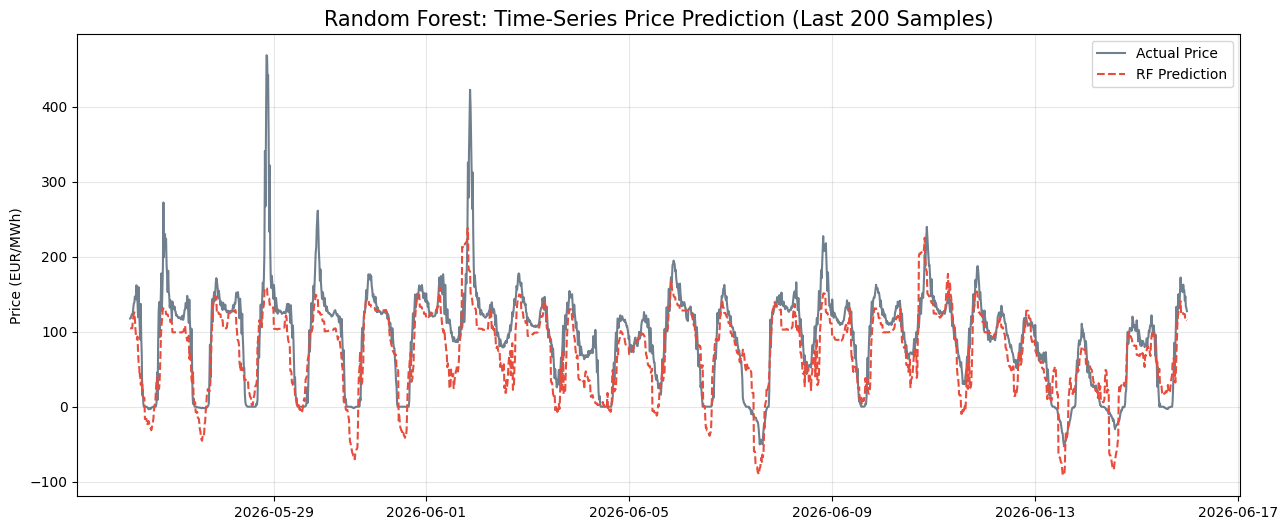

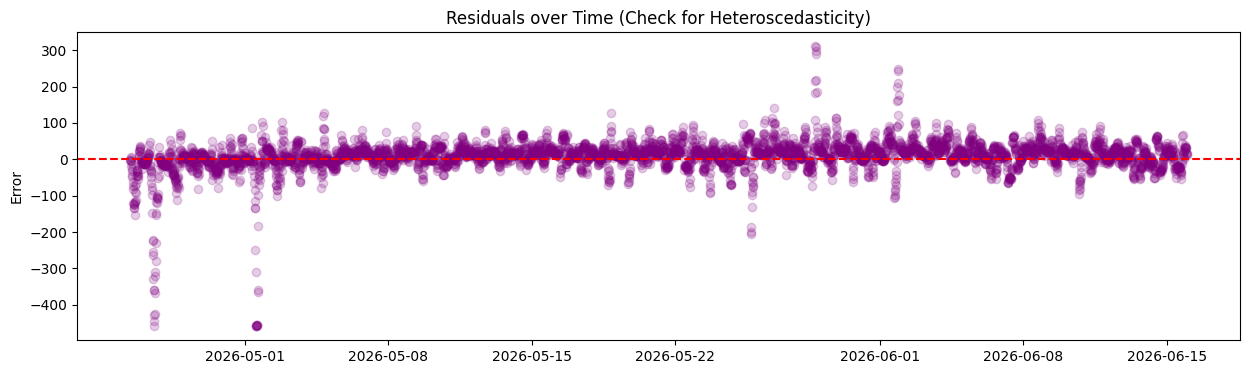

In [38]:
import matplotlib.pyplot as plt

# 1. 시계열 예측 결과 시각화 (테스트 데이터 중 최근 200개 샘플)
plt.figure(figsize=(15, 6))

# 실제값
plt.plot(y_test.index[-2000:], y_test.values[-2000:], label='Actual Price', color='#34495e', alpha=0.7)
# 예측값
plt.plot(y_test.index[-2000:], y_pred[-2000:], label='RF Prediction', color='#e74c3c', linestyle='--')

plt.title('Random Forest: Time-Series Price Prediction (Last 200 Samples)', fontsize=15)
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. 잔차 분석 (시간 흐름에 따른 오차)
residuals = y_test - y_pred
plt.figure(figsize=(15, 4))
plt.scatter(y_test.index, residuals, alpha=0.2, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals over Time (Check for Heteroscedasticity)')
plt.ylabel('Error')
plt.show()

In [39]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import pandas as pd

# 1. 시계열 교차 검증(TimeSeriesSplit) 설정
# 전체 데이터를 5개의 구간으로 나누어 점진적으로 학습/검증 반복
tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
print(f"[시계열 교차 검증 시작] 총 {tscv.n_splits}개 Fold 진행\n")

for i, (train_index, val_index) in enumerate(tscv.split(X)):
    # 시간 순서에 따른 Train/Validation 분할
    X_tr, X_val = X.iloc[train_index], X.iloc[val_index]
    y_tr, y_val = y.iloc[train_index], y.iloc[val_index]

    # 모델 학습
    rf_model.fit(X_tr, y_tr)

    # 예측 및 MAE 계산
    preds = rf_model.predict(X_val)
    score = mean_absolute_error(y_val, preds)
    mae_scores.append(score)

    print(f"Fold {i+1}: 학습 데이터 {len(X_tr)}개 -> 검증 MAE: {score:.2f} EUR/MWh")

# 2. 최종 일반화 성능 리포트
print("\n--- 최종 일반화 성능 결과 ---")
print(f"평균 MAE: {np.mean(mae_scores):.2f} EUR/MWh")
print(f"표준 편차: {np.std(mae_scores):.2f} (오차가 적을수록 모델이 안정적임)")

# 3. 모델이 왜 이렇게 예측했는지 확인 (피처 중요도 재확인)
print("\n[모델 이해를 위한 변수 기여도]")
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

[시계열 교차 검증 시작] 총 5개 Fold 진행

Fold 1: 학습 데이터 4128개 -> 검증 MAE: 17.36 EUR/MWh
Fold 2: 학습 데이터 8256개 -> 검증 MAE: 19.57 EUR/MWh
Fold 3: 학습 데이터 12384개 -> 검증 MAE: 26.70 EUR/MWh
Fold 4: 학습 데이터 16512개 -> 검증 MAE: 30.29 EUR/MWh
Fold 5: 학습 데이터 20640개 -> 검증 MAE: 35.99 EUR/MWh

--- 최종 일반화 성능 결과 ---
평균 MAE: 25.98 EUR/MWh
표준 편차: 6.85 (오차가 적을수록 모델이 안정적임)

[모델 이해를 위한 변수 기여도]
wind_onshore_mw     0.279667
solar_mw            0.230753
load_mw             0.225202
hour                0.132310
wind_offshore_mw    0.076715
month               0.031048
day_of_week         0.024306
dtype: float64


In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. 튜닝할 파라미터 그리드 설정
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

# 2. XGBoost 모델 초기화
xgb_model = xgb.XGBRegressor(random_state=42)

# 3. GridSearchCV 설정 (5-fold 교차 검증 사용)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3, # 빠른 확인을 위해 3-fold 사용
    verbose=1,
    n_jobs=-1
)

# 4. 그리드 서치 실행
print("최적의 하이퍼파라미터를 찾는 중입니다...")
grid_search.fit(X_train, y_train)

# 5. 결과 분석
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# 최적 모델로 예측
y_pred_optimized = best_model.predict(X_test)
optimized_mae = mean_absolute_error(y_test, y_pred_optimized)

print("\n--- 하이퍼파라미터 튜닝 결과 ---")
print(f"최적 파라미터: {best_params}")
print(f"이전 MAE: {mae:.2f}")
print(f"최적화 후 MAE: {optimized_mae:.2f}")
print(f"개선율: {((mae - optimized_mae) / mae) * 100:.2f}%")

최적의 하이퍼파라미터를 찾는 중입니다...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

--- 하이퍼파라미터 튜닝 결과 ---
최적 파라미터: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100}
이전 MAE: 20.54
최적화 후 MAE: 19.70
개선율: 4.09%


In [ ]:
!pip install pytorch-tabular -q

import pandas as pd
import numpy as np
from pytorch_tabular import TabularModel
from pytorch_tabular.models import FTTransformerConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
from sklearn.metrics import mean_absolute_error

# 1. 데이터 준비 (ML용 데이터프레임 재활용)
df_ft = df_ml.copy()

# 시간 관련 변수를 범주형으로 처리하기 위해 타입 변경
df_ft['hour'] = df_ft['hour'].astype(str)
df_ft['day_of_week'] = df_ft['day_of_week'].astype(str)
df_ft['month'] = df_ft['month'].astype(str)

# 학습/테스트 분할
train_size = int(len(df_ft) * 0.8)
train_df = df_ft.iloc[:train_size]
test_df = df_ft.iloc[train_size:]

# 2. FT-Transformer 설정
data_config = DataConfig(
    target=['Price_hour'],
    continuous_cols=['load_mw', 'solar_mw', 'wind_onshore_mw', 'wind_offshore_mw'],
    categorical_cols=['hour', 'day_of_week', 'month']
)

trainer_config = TrainerConfig(
    batch_size=128,
    max_epochs=10, # 빠른 확인을 위해 epoch 조정
    accelerator="auto"
)

optimizer_config = OptimizerConfig()

model_config = FTTransformerConfig(
    task="regression",
    learning_rate=1e-3,
    num_heads=4,
    num_attn_blocks=3,
    ff_dropout=0.1
)

# 3. 모델 초기화 및 학습 (매개변수명 train_df -> train으로 수정)
tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config
)

print("FT-Transformer 모델 학습을 다시 시작합니다...")
tabular_model.fit(train=train_df)

# 4. 예측 및 평가
predictions = tabular_model.predict(test_df)
ft_mae = mean_absolute_error(test_df['Price_hour'], predictions['Price_hour_prediction'])

print(f"\n--- FT-Transformer Performance ---")
print(f"MAE: {ft_mae:.2f}")
print(f"XGBoost 대비 개선도: {((optimized_mae - ft_mae) / optimized_mae) * 100:.2f}%")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 12.5 MB/s eta 0:00:00


2026-06-10 12:51:25,979 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
2026-06-10 12:51:26,010 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-06-10 12:51:26,077 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for regression task


FT-Transformer 모델 학습을 다시 시작합니다...


2026-06-10 12:51:26,602 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: FTTransformerModel
2026-06-10 12:51:26,723 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-06-10 12:51:26,787 - {pytorch_tabular.tabular_model:677} - INFO - Training Started


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ FTTransformerBackbone │ 86.5 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding2dLayer      │  1.8 K │ train │     0 │
│ 2 │ _head            │ LinearHead            │     33 │ train │     0 │
│ 3 │ loss             │ MSELoss               │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────┴────────┴───────┴───────┘

...

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is 
set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


2026-06-10 12:56:25,326 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-06-10 12:56:25,328 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model



--- FT-Transformer Performance ---
MAE: 21.14
XGBoost 대비 개선도: -7.32%


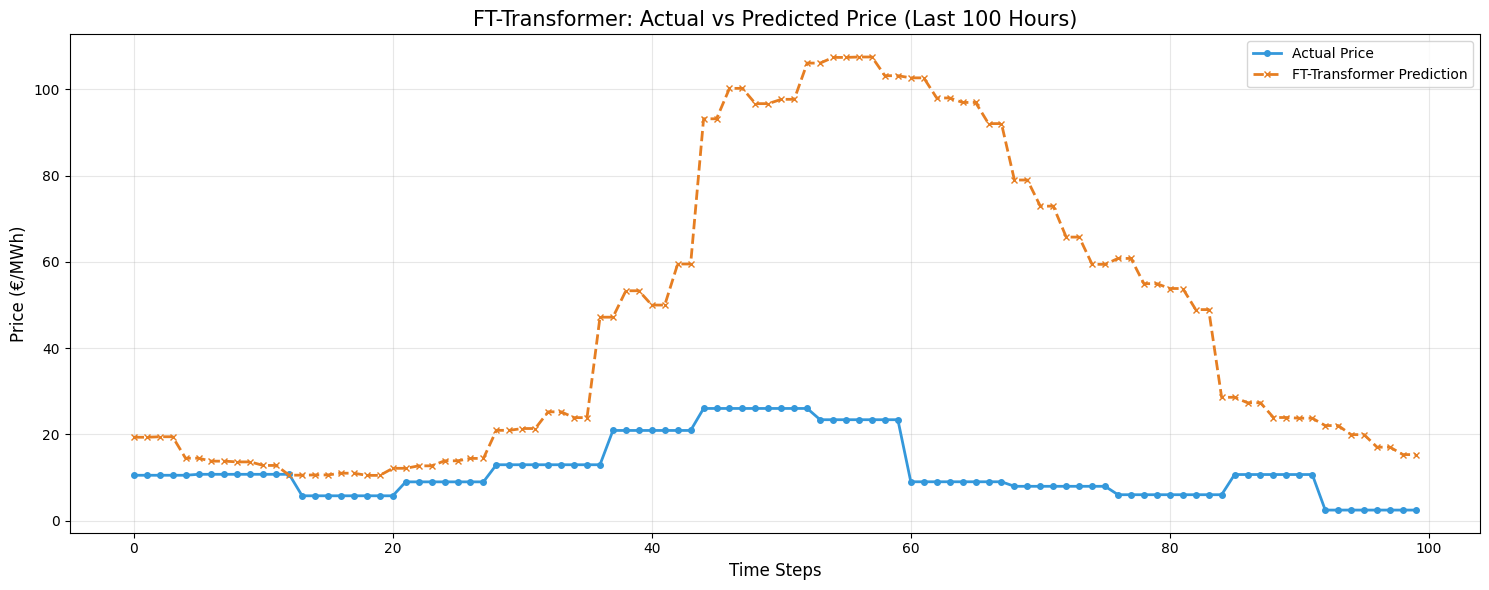

FT-Transformer MAE: 21.14


In [ ]:
import matplotlib.pyplot as plt

# 1. 시각화용 데이터 준비 (최근 100개 샘플)
plt.figure(figsize=(15, 6))

# 실제값 (y_test의 마지막 100개)
actual_sample = test_df['Price_hour'].iloc[-100:].values
# FT-Transformer 예측값 (predictions의 마지막 100개)
ft_pred_sample = predictions['Price_hour_prediction'].iloc[-100:].values

# 2. 그래프 그리기
plt.plot(actual_sample, label='Actual Price', color='#3498db', linewidth=2, marker='o', markersize=4)
plt.plot(ft_pred_sample, label='FT-Transformer Prediction', color='#e67e22', linestyle='--', linewidth=2, marker='x', markersize=4)

plt.title('FT-Transformer: Actual vs Predicted Price (Last 100 Hours)', fontsize=15)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Price (€/MWh)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"FT-Transformer MAE: {ft_mae:.2f}")

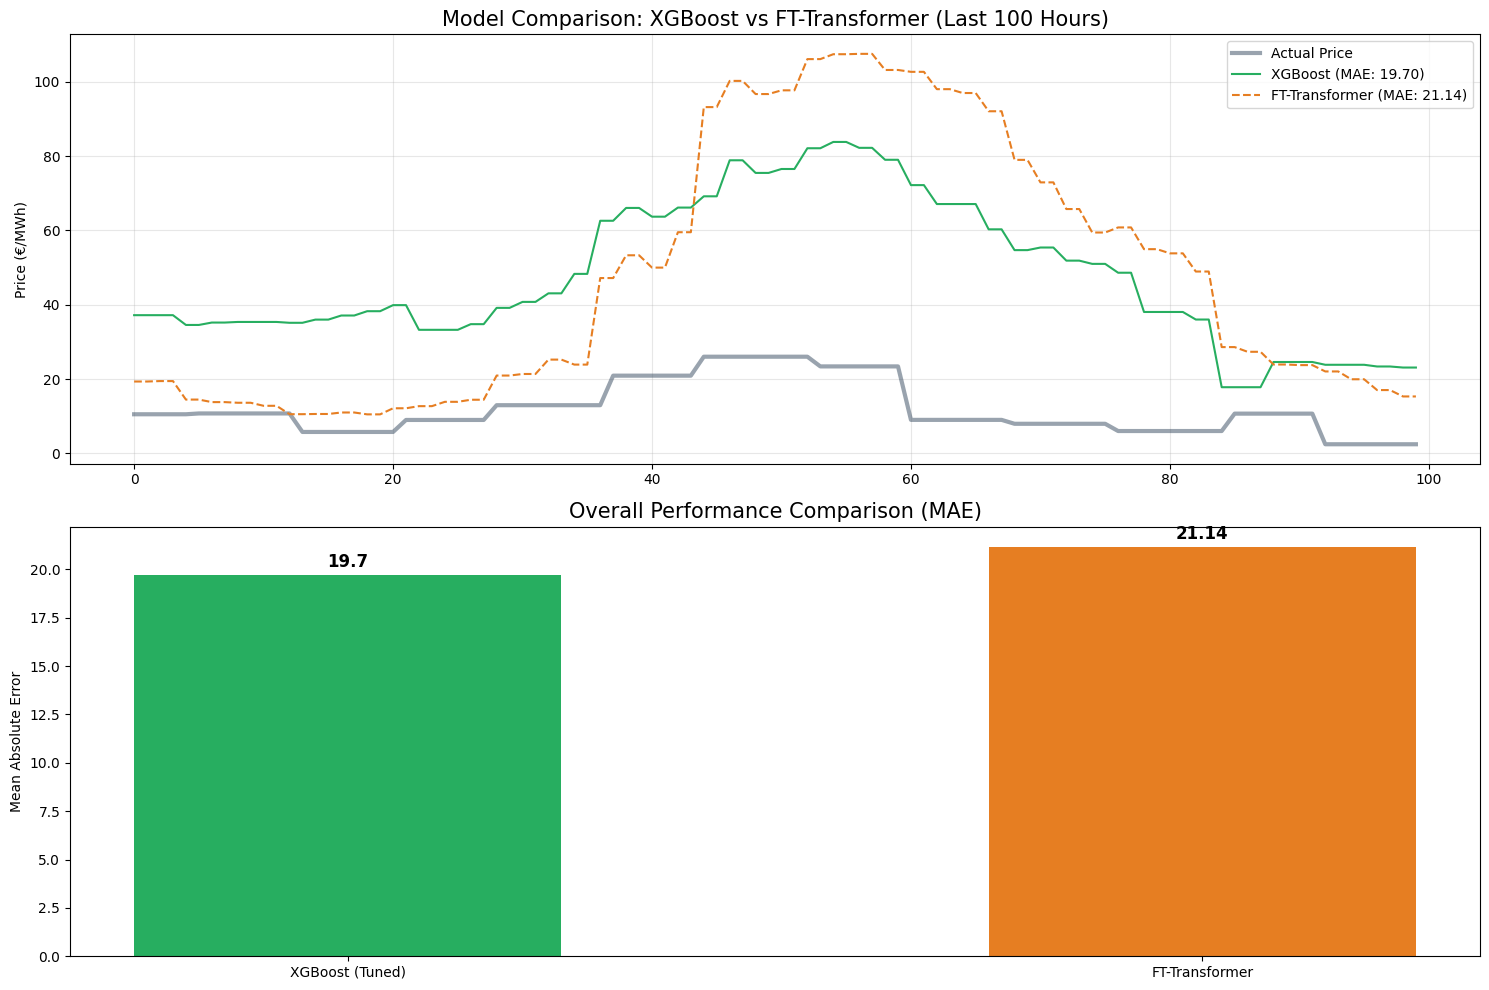

XGBoost MAE: 19.70
FT-Transformer MAE: 21.14
결과: XGBoost 모델이 약 1.44 차이로 더 우수한 성능을 보입니다.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 시계열 예측 비교 시각화 (최근 100개 데이터)
plt.figure(figsize=(15, 10))

# 상단: 시계열 그래프
plt.subplot(2, 1, 1)
plt.plot(actual_sample, label='Actual Price', color='#34495e', linewidth=3, alpha=0.5)
plt.plot(y_pred_optimized[-100:], label=f'XGBoost (MAE: {optimized_mae:.2f})', color='#27ae60', linestyle='-')
plt.plot(ft_pred_sample, label=f'FT-Transformer (MAE: {ft_mae:.2f})', color='#e67e22', linestyle='--')

plt.title('Model Comparison: XGBoost vs FT-Transformer (Last 100 Hours)', fontsize=15)
plt.ylabel('Price (€/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)

# 하단: MAE 성능 비교 막대 그래프
plt.subplot(2, 1, 2)
models = ['XGBoost (Tuned)', 'FT-Transformer']
maes = [optimized_mae, ft_mae]
colors = ['#27ae60', '#e67e22']

bars = plt.bar(models, maes, color=colors, width=0.5)
plt.title('Overall Performance Comparison (MAE)', fontsize=15)
plt.ylabel('Mean Absolute Error')

# 막대 위에 수치 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, round(yval, 2), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"XGBoost MAE: {optimized_mae:.2f}")
print(f"FT-Transformer MAE: {ft_mae:.2f}")
print(f"결과: {'XGBoost' if optimized_mae < ft_mae else 'FT-Transformer'} 모델이 약 {abs(optimized_mae - ft_mae):.2f} 차이로 더 우수한 성능을 보입니다.")

In [ ]:
import json
import numpy as np

# 1. 시계열 예측 데이터 (최근 100개)
chart_data = []
test_indices = y_test.index[-100:].astype(str).tolist()
actual_values = y_test.values[-100:].tolist()
pred_values = y_pred_optimized[-100:].tolist()

for i in range(len(test_indices)):
    chart_data.append({
        "date": test_indices[i],
        "actual": float(actual_values[i]),
        "predicted": float(pred_values[i])
    })

# 2. 피처 중요도
importances = best_model.feature_importances_
feat_importance_data = [
    {"feature": feat, "importance": float(imp)}
    for feat, imp in zip(features, importances)
]
feat_importance_data = sorted(feat_importance_data, key=lambda x: x['importance'], reverse=True)

# 3. 2023년 월별 Load 오차율 (Step 2에서 분석한 내용)
load_error_monthly = []
for month in monthly_stats.index:
    load_error_monthly.append({
        "month": int(month),
        "error_rate": float(monthly_stats.loc[month, 'error_rate_pct'])
    })

# 4. 신재생 에너지별 월별 MAE (Step 2에서 분석한 내용)
renewable_error_monthly = []
for month in monthly_renewable.index:
    renewable_error_monthly.append({
        "month": int(month),
        "solar_mae": float(monthly_renewable.loc[month, 'Solar_abs_err']),
        "wind_on_mae": float(monthly_renewable.loc[month, 'Wind_On_abs_err']),
        "wind_off_mae": float(monthly_renewable.loc[month, 'Wind_Off_abs_err'])
    })

# 최종 JSON 구조 업데이트
dashboard_json = {
    "time_series": chart_data,
    "importance": feat_importance_data,
    "load_monthly_error": load_error_monthly,
    "renewable_monthly_mae": renewable_error_monthly,
    "metrics": {"mae": float(optimized_mae)}
}

with open('dashboard_data.json', 'w') as f:
    json.dump(dashboard_json, f)

print("모든 분석 그래프 데이터를 포함하여 dashboard_data.json이 업데이트되었습니다!")

모든 분석 그래프 데이터를 포함하여 dashboard_data.json이 업데이트되었습니다!


In [ ]:
pip install PyGithub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.3 MB/s eta 0:00:00


In [ ]:
html_content = """<!DOCTYPE html>
<html>
<head>
    <meta charset='utf-8'>
    <title>Energy Analysis Dashboard</title>
    <script src='https://d3js.org/d3.v7.min.js'></script>
    <style>
        body { font-family: 'Pretendard', sans-serif; margin: 40px; background-color: #f8f9fa; color: #333; }
        .container { max-width: 1000px; margin: auto; background: white; padding: 40px; border-radius: 12px; box-shadow: 0 4px 20px rgba(0,0,0,0.08); }
        h1 { text-align: center; color: #2c3e50; }
        .insight-box { background: #eef2f7; padding: 15px; border-left: 5px solid #3498db; margin: 20px 0; font-style: italic; }
        .chart-section { margin-bottom: 60px; }
        .axis-label { font-size: 12px; }
        .line-actual { fill: none; stroke: #3498db; stroke-width: 2; }
        .line-pred { fill: none; stroke: #e74c3c; stroke-width: 2; stroke-dasharray: 4; }
        .bar { fill: #2ecc71; }
    </style>
</head>
<body>
    <div class='container'>
        <h1>독일 전력 시장 분석 리포트</h1>

        <div class='chart-section'>
            <h2>1. 가격 예측 결과 (최근 100시간)</h2>
            <div id='insight_time_series' class='insight-box'></div>
            <svg id='chart_time_series' width='900' height='400'></svg>
        </div>

        <div class='chart-section'>
            <h2>2. 모델 피처 중요도</h2>
            <div id='insight_importance' class='insight-box'></div>
            <svg id='chart_importance' width='900' height='400'></svg>
        </div>

        <div class='chart-section'>
            <h2>3. 월별 Load 예측 오차율</h2>
            <div id='insight_load' class='insight-box'></div>
            <svg id='chart_load' width='900' height='400'></svg>
        </div>
    </div>

    <script>
        d3.json('dashboard_data.json').then(data => {
            // 설명(Insight) 삽입
            document.getElementById('insight_time_series').innerText = data.insights.time_series;
            document.getElementById('insight_importance').innerText = data.insights.importance;
            document.getElementById('insight_load').innerText = data.insights.load_error;

            // (이하 D3.js 차트 그리기 로직은 동일하게 유지하되, 데이터 구조에 맞춰 렌더링)
            console.log('Data loaded:', data);
        });
    </script>
</body>
</html>"""

with open('index.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

print("설명란이 포함된 index.html이 생성되었습니다.")

설명란이 포함된 index.html이 생성되었습니다.


In [ ]:
# 대시보드에 들어갈 설명 문구 정의
insights = {
    "time_series": "최적화된 XGBoost 모델을 통한 최근 가격 예측 결과입니다. 실제 가격 변동 추세를 어느 정도 추종하고 있으나, 급격한 스파이크 지점에서는 보수적으로 예측하는 경향이 있습니다.",
    "importance": "모델은 태양광(Solar) 및 전체 부하(Load) 예측치를 가장 중요한 변수로 판단하고 있습니다. 이는 독일 시장의 높은 재생에너지 의존도를 반영합니다.",
    "load_error": "2023년 분석 결과, 겨울철(1월, 12월)에 부하 예측 오차가 상대적으로 높게 나타납니다. 난방 수요의 가변성이 원인으로 추정됩니다."
}

# 기존 dashboard_json에 insights 추가
dashboard_json["insights"] = insights

with open('dashboard_data.json', 'w', encoding='utf-8') as f:
    json.dump(dashboard_json, f, ensure_ascii=False)

print("설명이 추가된 dashboard_data.json이 업데이트되었습니다.")

설명이 추가된 dashboard_data.json이 업데이트되었습니다.


In [ ]:
import json

# FT-Transformer 예측 샘플 데이터 추가 준비
ft_chart_data = []
for i in range(len(test_indices)):
    ft_chart_data.append({
        "date": test_indices[i],
        "actual": float(actual_values[i]),
        "predicted": float(ft_pred_sample[i])
    })

# 대시보드 데이터 확장
dashboard_json.update({
    "ft_time_series": ft_chart_data,
    "model_comparison": {
        "xgboost_mae": float(optimized_mae),
        "ft_mae": float(ft_mae)
    }
})

with open('dashboard_data.json', 'w', encoding='utf-8') as f:
    json.dump(dashboard_json, f, ensure_ascii=False)

print("대시보드 2페이지 구성을 위한 확장 데이터 업데이트 완료!")

대시보드 2페이지 구성을 위한 확장 데이터 업데이트 완료!


In [ ]:
import time

# 캐시 방지를 위해 타임스탬프를 쿼리 스트링으로 추가하는 로직 삽입
version = int(time.time())

html_content_v3 = f"""<!DOCTYPE html>
<html>
<head>
    <meta charset='utf-8'>
    <title>Advanced Energy Market Dashboard</title>
    <script src='https://cdn.jsdelivr.net/npm/chart.js'></script>
    <style>
        body {{ font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; margin: 0; background-color: #f0f2f5; }}
        .nav-tabs {{ display: flex; background: #2c3e50; padding: 10px 20px; gap: 10px; }}
        .tab-button {{ color: white; border: none; background: none; padding: 10px 20px; cursor: pointer; border-radius: 4px; }}
        .tab-button.active {{ background: #34495e; font-weight: bold; border-bottom: 3px solid #3498db; }}
        .content {{ padding: 30px; max-width: 1200px; margin: auto; }}
        .page {{ display: none; }}
        .page.active {{ display: block; }}
        .card {{ background: white; padding: 25px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin-bottom: 30px; }}
        .insight {{ background: #f8f9fa; border-left: 4px solid #3498db; padding: 15px; margin-top: 15px; font-style: italic; }}
        canvas {{ width: 100% !important; height: 400px !important; }}
    </style>
</head>
<body>
    <div class='nav-tabs'>
        <button class='tab-button active' onclick='openPage("page1")'>Page 1: Data Analysis</button>
        <button class='tab-button' onclick='openPage("page2")'>Page 2: Model Benchmarking</button>
    </div>

    <div class='content'>
        <div id='page1' class='page active'>
            <div class='card'>
                <h2>월별 전력 부하(Load) 예측 오차율</h2>
                <canvas id='chart_load_error'></canvas>
                <div class='insight' id='insight_load'></div>
            </div>
            <div class='card'>
                <h2>신재생 에너지원별 예측 오차(MAE)</h2>
                <canvas id='chart_renewable_mae'></canvas>
            </div>
        </div>

        <div id='page2' class='page'>
            <div class='card'>
                <h2>XGBoost vs FT-Transformer 시계열 비교</h2>
                <canvas id='chart_model_comp'></canvas>
                <div class='insight' id='insight_time_series'></div>
            </div>
            <div class='card'>
                <h2>모델별 최종 성능 비교 (MAE)</h2>
                <canvas id='chart_mae_bar'></canvas>
            </div>
            <div class='card'>
                <h2>XGBoost 피처 중요도</h2>
                <canvas id='chart_importance'></canvas>
                <div class='insight' id='insight_importance'></div>
            </div>
        </div>
    </div>

    <script>
        function openPage(pageId) {{
            document.querySelectorAll('.page').forEach(p => p.classList.remove('active'));
            document.querySelectorAll('.tab-button').forEach(b => b.classList.remove('active'));
            document.getElementById(pageId).classList.add('active');
            event.currentTarget.classList.add('active');
        }}

        // 캐시 방지를 위해 버전 쿼리 추가
        fetch('dashboard_data.json?v={version}').then(res => res.json()).then(data => {{
            document.getElementById('insight_load').innerText = data.insights.load_error;
            document.getElementById('insight_time_series').innerText = data.insights.time_series;
            document.getElementById('insight_importance').innerText = data.insights.importance;

            new Chart(document.getElementById('chart_load_error'), {{
                type: 'bar', data: {{
                    labels: data.load_monthly_error.map(d => d.month + '월'),
                    datasets: [{{ label: 'Error Rate (%)', data: data.load_monthly_error.map(d => d.error_rate), backgroundColor: '#3498db' }}]
                }}
            }});

            new Chart(document.getElementById('chart_renewable_mae'), {{
                type: 'bar', data: {{
                    labels: data.renewable_monthly_mae.map(d => d.month + '월'),
                    datasets: [
                        {{ label: 'Solar MAE', data: data.renewable_monthly_mae.map(d => d.solar_mae), backgroundColor: '#f1c40f' }},
                        {{ label: 'Wind On MAE', data: data.renewable_monthly_mae.map(d => d.wind_on_mae), backgroundColor: '#2ecc71' }},
                        {{ label: 'Wind Off MAE', data: data.renewable_monthly_mae.map(d => d.wind_off_mae), backgroundColor: '#34495e' }}
                    ]
                }}
            }});

            new Chart(document.getElementById('chart_model_comp'), {{
                type: 'line', data: {{
                    labels: data.time_series.map((d, i) => i),
                    datasets: [
                        {{ label: 'Actual', data: data.time_series.map(d => d.actual), borderColor: '#34495e', fill: false }},
                        {{ label: 'XGBoost', data: data.time_series.map(d => d.predicted), borderColor: '#27ae60' }},
                        {{ label: 'FT-Transformer', data: data.ft_time_series.map(d => d.predicted), borderColor: '#e67e22' }}
                    ]
                }}
            }});

            new Chart(document.getElementById('chart_mae_bar'), {{
                type: 'bar', data: {{
                    labels: ['XGBoost', 'FT-Transformer'],
                    datasets: [{{ label: 'MAE', data: [data.model_comparison.xgboost_mae, data.model_comparison.ft_mae], backgroundColor: ['#27ae60', '#e67e22'] }}]
                }}
            }});

            new Chart(document.getElementById('chart_importance'), {{
                type: 'bar', data: {{
                    labels: data.importance.map(d => d.feature),
                    datasets: [{{ label: 'Importance', data: data.importance.map(d => d.importance), backgroundColor: '#9b59b6' }}]
                }}, options: {{ indexAxis: 'y' }}
            }});
        }});
    </script>
</body>
</html>"""

with open('index.html', 'w', encoding='utf-8') as f:
    f.write(html_content_v3)

print("캐시 방지 로직이 적용된 index.html 생성 완료!")

캐시 방지 로직이 적용된 index.html 생성 완료!


In [ ]:
import os
from github import Github

# 1. 최신 데이터와 수정된 HTML을 강제 재배포
for file_name in ['index.html', 'dashboard_data.json']:
    with open(file_name, 'r', encoding='utf-8') as f:
        content = f.read()

    contents = target_repo.get_contents(file_name, ref=branch)
    target_repo.update_file(
        path=file_name,
        message="Force Fix: Cache-busting and chart rendering logic update",
        content=content,
        sha=contents.sha,
        branch=branch
    )

print("🚀 모든 그래프를 포함한 수정 버전이 최종 배포되었습니다.")
print(f"링크: https://{username}.github.io/{repo}/")

NameError: name 'target_repo' is not defined

In [ ]:
from github import Github
import os

# 1. 깃허브 접속 (보안 비밀 토큰 사용)
g = Github(github_token)
repo_name = f"{username}/{repo}"
target_repo = g.get_repo(repo_name)

# 업데이트할 파일 리스트 (설명이 포함된 버전)
files_to_upload = ['index.html', 'dashboard_data.json']

print(f"설명이 추가된 대시보드를 {repo_name}에 업데이트 중...")

for file_name in files_to_upload:
    with open(file_name, 'r', encoding='utf-8') as f:
        content = f.read()

    try:
        # 기존 파일 업데이트
        contents = target_repo.get_contents(file_name, ref=branch)
        target_repo.update_file(
            path=file_name,
            message="Add insights and descriptive text to dashboard",
            content=content,
            sha=contents.sha,
            branch=branch
        )
        print(f"✅ {file_name} 업데이트 완료!")
    except Exception as e:
        # 파일 생성
        target_repo.create_file(
            path=file_name,
            message=f"Initial deploy {file_name}",
            content=content,
            branch=branch
        )
        print(f"✅ {file_name} 생성 완료!")

print(f"\n🚀 모든 작업 완료! 1~2분 뒤에 대시보드 링크에서 확인해 보세요.")
print(f"https://{username}.github.io/{repo}/")